In [5]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd
from datetime import timedelta, datetime
import joblib
from datetime import datetime, timedelta
from scipy.special import softmax
from workalendar.america import Brazil
import ast
import warnings
warnings.filterwarnings("ignore")
import pandas_ta as pdta

OHLCV_PATH = "ohlcv"
SENTIMENT_PATH = "ebd_fbrt"

OPEN_DATE = "2024-04-01"
CLOSE_DATE = "2024-08-31"

END_TRAIN_DATE = "2024-07-20"

def returns_indicator(close, length, *args, **kwargs):
    """
    Calculates a returns indicator based on the ratio between the current returns and
    its rolling average.
    
    Parameters:
        close (pd.Series): Historical series of closing prices.
        length (int): Window size for calculating the rolling average of the returns.
        *args: Additional positional arguments (not used).
        **kwargs: Additional keyword arguments (not used).
    
    Returns:
        pd.Series: Returns ratio values.
    """
    returns = close.pct_change()
    returns = abs(returns)
    rolling_returns = returns.rolling(window=length).mean()
    returns_ratio = returns / rolling_returns
    return returns_ratio


def bollinger_bands_indicator(close, length, *args, **kwargs): 
    """
    Calculates a Bollinger Bands score based on the z-score of the closing prices.

    Parameters:
        close (pd.Series): Historical series of closing prices.
        length (int): Window size for calculating the rolling mean and standard deviation.
        *args: Additional positional arguments (not used).
        **kwargs: Additional keyword arguments (not used).

    Returns:
        pd.Series: Bollinger Bands scores (z-scores of the closing prices).
    """
    rolling_mean = close.rolling(window=length).mean()
    rolling_std = close.rolling(window=length).std()
    bb_score = (close - rolling_mean) / rolling_std
    return bb_score

def rsi_func(close, length=14, *args, **kwargs):
    """
    Calculates the Relative Strength Index (RSI) using the Moving Average Wilder (RMA).
    
    Parameters:
        close (pd.Series): Historical series of closing prices.
        length (int): length for RSI calculation (default: 14).
        
    Returns:
        pd.Series: RSI values.
    """
    delta = close.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    avg_up = up.rolling(window=length, min_periods=length).mean()
    avg_down = down.rolling(window=length, min_periods=length).mean()
        
    for i in range(length + 1, len(avg_up)):
        avg_up.iloc[i] = (avg_up.iloc[i-1] * (length - 1) + up.iloc[i]) / length
        avg_down.iloc[i] = (avg_down.iloc[i-1] * (length - 1) + down.iloc[i]) / length
    m_div = avg_up / avg_down
    rsi = 100 - (100 / (1 + m_div))
    return rsi


def stochastic_rsi_func(close, rsi_length=14, length=14, *args, **kwargs):
    """
    Calculates the Stochastic RSI based on the RSI.
    
    Parameters:
        close (pd.Series): Historical series of closing prices.
        rsi_length (int): RSI length (default: 14).
        length (int): Stochastic RSI length (default: 14).
        
    Returns:
        pd.Series: Stochastic RSI values.
    """
    rsi = rsi_func(close, length=rsi_length)
    min_rsi = rsi.rolling(window=length).min()
    max_rsi = rsi.rolling(window=length).max()
    stoch_rsi = 100*(rsi - min_rsi) / (max_rsi - min_rsi)    
    return stoch_rsi

TA_INFO = {
        'stochrsi':{
            "method": stochastic_rsi_func,
            "period": 14,
            "secondary_period": 14},
        'rsi':{
            "method": rsi_func,
            "period": 14},
        'atr':{
            "method": pdta.atr,
            "period": 14},
        'mom':{
            "method": pdta.mom,
            "period": 14},
        'cci':{
            "method": pdta.cci,
            "period": 14},
        'stoch':{
            "method": pdta.stoch,
            "period": 14},
        
        'macd':{
            "method": pdta.macd,
            "period": 12,
            "secondary_period": 26,
            "signal_period": 9},
        'bollinger_bands':{
            "method": bollinger_bands_indicator,
            "period": 20},
        'returns':{
            "method": returns_indicator,
            "period": 14}
    }

class RLDatabase:
    def __init__(self,
                 start_train: str,
                 end_train: str,
                 end_test: str,
                 ticker: str = 'AAPL',
                 time_window: int = 60,
                 include_sentiment_info:bool = False,
                 normalize_data: bool = True):
        
        self.start_train = pd.to_datetime(start_train)
        self.end_train = pd.to_datetime(end_train)
        self.end_test = pd.to_datetime(end_test)
        self.ticker = ticker
        self.time_window = time_window
        self.include_sentiment_info = include_sentiment_info
        self.normalize_data = normalize_data
        self.ohlcv = None
        self.ta_info = {}
        self.ta_df = None
        self.sentiment_df = None
        self.train_test_info = None
        
    def _create_ohlcv_df(self):
        if self.ohlcv is not None:
            return self.ohlcv
        try:
            ohlcv = pd.read_csv(f"{OHLCV_PATH}/{self.ticker}_ohlcv.csv", index_col=0)
            ohlcv.index = pd.to_datetime(ohlcv.index)
            ohlcv.columns = ['open', 'high', 'low', 'close', 'volume']
            self.ohlcv = ohlcv
        except Exception as e:
            print("Error in creating OHLCV df: {e}")
        return self.ohlcv
    
    def _create_ta_df(self):
        if self.ta_df is not None:
            return self.ta_df
        try:
            ohlcv = self._create_ohlcv_df()
            for indicator in TA_INFO.keys():
                technical_indicator = TA_INFO[indicator]["method"]
                ta_period = TA_INFO[indicator]['period']
                if indicator == 'stochrsi':
                        secondary_ta_period = TA_INFO[indicator]['secondary_period']
                        complete_ta_data = technical_indicator(close=ohlcv['close'], length=ta_period,
                                                        rsi_length = secondary_ta_period, k = 1, d = 1)
                elif indicator == 'macd':
                    secondary_ta_period = TA_INFO[indicator]['secondary_period']
                    signal_period = TA_INFO[indicator]['signal_period']
                    complete_ta_data = technical_indicator(close = ohlcv['close'], fast = ta_period,
                                                    slow = secondary_ta_period, signal = signal_period)
                    complete_ta_data = complete_ta_data[f"MACDh_{ta_period}_{secondary_ta_period}_{signal_period}"]
                elif indicator == 'stoch':
                    complete_ta_data = technical_indicator(high = ohlcv['high'], 
                                                        low = ohlcv['low'], 
                                                        close = ohlcv['close'], 
                                                        k = ta_period, d = 1, smooth_k = 1)
                    complete_ta_data = complete_ta_data[f"STOCHk_{ta_period}_1_1"]
                else:
                    indicator_kwargs = {
                        'close': ohlcv['close'],
                        'high': ohlcv['high'],
                        'low': ohlcv['low'],
                        'volume': ohlcv['volume'],
                        'length': ta_period,
                        'k':1, 'd':1,
                    }
                    complete_ta_data = technical_indicator(**indicator_kwargs)   
                self.ta_info[indicator] = complete_ta_data    
        except Exception as e:
            print(f"Error in creating TA df: {e}")
        self.ta_df = pd.DataFrame(self.ta_info)
        return self.ta_df
    
    def _create_finbert_score(self, df):
        finbert_score = []
        for _, row in df.iterrows():
            finbert_info = ast.literal_eval(row["finbert"]) # neutral; positive; negative
            positive_info = finbert_info[1]
            negative_info = finbert_info[2]
            sentiment_score = positive_info - negative_info
            finbert_score.append(sentiment_score)
        df['finbert_score'] = finbert_score
        return df
    
    def _create_sentiment_by_news(self, df):
        df_news = {}
        grouped_df = df.groupby("date")
        for group in grouped_df:
            index_date = group[0]
            sentiment_info = group[1]
            weights = 1 / sentiment_info['embedding_distance'] 
            sentiment_score = (sentiment_info['finbert_score'] * weights).sum() / weights.sum()
            df_news[index_date] = sentiment_score
        return pd.DataFrame.from_dict(df_news, orient='index', columns=['sentiment_score'])

    def _create_sentiment_index(self, news_df, start_time, end_time, lookback_window='1D'):
        news_df.index = pd.to_datetime(news_df.index)
        max_score = news_df['sentiment_score'].abs().max()
        news_df['normalized_sentiment'] = news_df['sentiment_score'] / max_score
        
        time_index = pd.date_range(start=start_time, end=end_time, freq="1T")
        sentiment_index = pd.Series(0.0, index=time_index)

        lookback_window_timedelta = pd.Timedelta(lookback_window)

        for current_time in time_index:
            window_start = current_time - lookback_window_timedelta
            relevant_news = news_df[(news_df.index > window_start) & (news_df.index <= current_time)]

            if not relevant_news.empty:
                time_deltas = (current_time - relevant_news.index).total_seconds()
                time_deltas = np.array(time_deltas) 
                weights = np.exp(-time_deltas / lookback_window_timedelta.total_seconds())
                weighted_sentiment = (relevant_news['normalized_sentiment'].values * weights).sum()
                sentiment_index[current_time] = weighted_sentiment / weights.sum()
            else:
                previous_value = sentiment_index.get(current_time - pd.Timedelta("1T"), 0.0)
                sentiment_index[current_time] = previous_value * 0.9
        sentiment_index = pd.DataFrame(sentiment_index, columns=["sentiment_score"])
        return sentiment_index
    
    def _create_sentiment_df(self):
        if self.sentiment_df is not None:
            return self.sentiment_df
        try:
            ebd_fbrt = pd.read_csv(f"{SENTIMENT_PATH}/{self.ticker}_ebd_fbrt.csv", index_col=0)
            ebd_fbrt.index = pd.to_datetime(ebd_fbrt.index)
            ebd_fbrt = self._create_finbert_score(ebd_fbrt)
            ebd_fbrt = self._create_sentiment_by_news(ebd_fbrt)
            ebd_fbrt = self._create_sentiment_index(ebd_fbrt, start_time=OPEN_DATE, end_time=CLOSE_DATE)
            self.sentiment_df = ebd_fbrt
            return self.sentiment_df
      
        except Exception as e:
            print(f"Error in creating sentiment df: {e}")
            
    def create_train_test_info(self):
        #if self.train_test_info is not None:
        #    return self.train_test_info
        ohlcv = self._create_ohlcv_df()
        ta_df = self._create_ta_df()
        base_info_df = pd.concat([ohlcv, ta_df], axis = 1)
        base_info_df.index = pd.to_datetime(base_info_df.index)
        close_info = base_info_df['close']
        close_info.name = "close_real"
        end_train_index = close_info.index.searchsorted(self.end_train)
        
        start_of_test = base_info_df.index[end_train_index - self.time_window]
        
        base_train_df = base_info_df.loc[self.start_train:self.end_train].dropna()
        base_test_df = base_info_df.loc[start_of_test:self.end_test].dropna()
        if self.normalize_data:
            scaler = StandardScaler()
            base_train_df = pd.DataFrame(scaler.fit_transform(base_train_df), columns=base_train_df.columns, index=base_train_df.index)
            base_test_df = pd.DataFrame(scaler.transform(base_test_df), columns=base_test_df.columns, index=base_test_df.index)
        train_df = pd.concat([close_info, base_train_df], axis=1)
        test_df = pd.concat([close_info, base_test_df], axis=1)
        if self.include_sentiment_info:
            sentiment_df = self._create_sentiment_df()
            train_df = pd.concat([train_df, sentiment_df], axis=1)
            test_df = pd.concat([test_df, sentiment_df], axis=1)
        train_df = train_df.dropna()
        test_df = test_df.dropna()
        self.train_test_info = {"train": train_df, "test": test_df}
        return self.train_test_info
  
        


In [9]:
import os

folder = 'news'
files = os.listdir(folder)
tickers = [f.split("_")[0] for f in files if os.path.isfile(os.path.join(folder, f))]
tickers

['BA',
 'MCD',
 'JNJ',
 'INTC',
 'BAC',
 'AMZN',
 'NVDA',
 'ORCL',
 'DIS',
 'GS',
 'GOOG',
 'MSFT',
 'TSLA',
 'META',
 'AAPL',
 'V',
 'PFE',
 'KO',
 'GE',
 'CAT',
 'XOM',
 'CVX',
 'DE',
 'F',
 'WMT']

In [11]:
for ticker in tickers:
    rldb = RLDatabase(ticker=ticker, 
                      start_train=OPEN_DATE, 
                      end_train=END_TRAIN_DATE, 
                      end_test=CLOSE_DATE, 
                      include_sentiment_info=False)
    info = rldb.create_train_test_info()
    train = info['train']
    test = info['test']
    train.to_csv(f"rl_dfs/train/{ticker}.csv", index=True)
    test.to_csv(f"rl_dfs/test/{ticker}.csv", index=True)
    print(f"\nCreated train and test for {ticker}")
    
    rldb = RLDatabase(ticker=ticker, 
                      start_train=OPEN_DATE, 
                      end_train=END_TRAIN_DATE, 
                      end_test=CLOSE_DATE, 
                      include_sentiment_info=True)
    info = rldb.create_train_test_info()
    train = info['train']
    test = info['test']
    train.to_csv(f"rl_dfs/train/{ticker}_sentiment.csv", index=True)
    test.to_csv(f"rl_dfs/test/{ticker}_sentiment.csv", index=True)
    print(f"Created train and test for {ticker} with sentiment")



Created train and test for BA
Created train and test for BA with sentiment

Created train and test for MCD
Created train and test for MCD with sentiment

Created train and test for JNJ
Created train and test for JNJ with sentiment

Created train and test for INTC
Created train and test for INTC with sentiment

Created train and test for BAC
Created train and test for BAC with sentiment

Created train and test for AMZN
Created train and test for AMZN with sentiment

Created train and test for NVDA
Created train and test for NVDA with sentiment

Created train and test for ORCL
Created train and test for ORCL with sentiment

Created train and test for DIS
Created train and test for DIS with sentiment

Created train and test for GS
Created train and test for GS with sentiment

Created train and test for GOOG
Created train and test for GOOG with sentiment

Created train and test for MSFT
Created train and test for MSFT with sentiment

Created train and test for TSLA
Created train and test 

In [12]:
pd.DataFrame(df0, columns=["sentimen_score"])

,sentimen_score
2024-04-01 00:00:00,0.000000
2024-04-01 00:01:00,0.000000
2024-04-01 00:02:00,0.000000
2024-04-01 00:03:00,0.000000
2024-04-01 00:04:00,0.000000
...,...
2024-08-30 23:56:00,0.266228
2024-08-30 23:57:00,0.266228
2024-08-30 23:58:00,0.266228
2024-08-30 23:59:00,0.266228


In [49]:
df = df0.loc[df0.index[:200]]
df

,sentiment_score,normalized_sentiment
2024-04-01 03:42:22,1.213531,0.102676
2024-04-01 07:05:00,5.321783,0.450273
2024-04-01 08:25:00,6.602519,0.558636
2024-04-01 09:50:00,4.164725,0.352375
2024-04-01 10:23:20,1.777095,0.150359
...,...,...
2024-04-11 13:11:00,6.586539,0.557284
2024-04-11 13:15:00,2.674986,0.226329
2024-04-11 13:30:41,0.738401,0.062476
2024-04-11 13:43:39,1.461442,0.123652


In [51]:


index = generate_sentiment_index(df, start_time='2024-04-01', end_time='2024-08-31')

<Axes: >

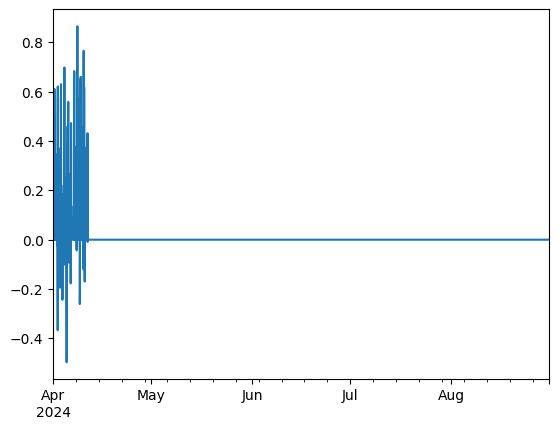

In [52]:
index.plot()

In [8]:
def calculate_sentiment_index(df, 
                              finbert_weight: float = 0.5, 
                              euclidean_distance_weight: float = 0.5, 
                              decay_rate: float = 0.01, 
                              lookback_window: str = '1D'):
    """
    Calcula um índice de sentimento ponderado por tempo e decaimento.
    
    Parâmetros:
        df (pd.DataFrame): DataFrame indexado por datetime contendo as colunas 'finbert_score' e 'euclidean_dist'.
        finbert_weight (float): Peso do score do FinBERT.
        euclidean_distance_weight (float): Peso da distância euclidiana.
        decay_rate (float): Taxa de decaimento do índice em direção à neutralidade (0).
        lookback_window (str): Período de análise para considerar notícias.

    Retorna:
        pd.DataFrame: DataFrame contendo os índices de sentimento e seus respectivos timestamps.
    """
    results = []  # Lista para armazenar os resultados (datetime e índice)
    df.groupby(df.index)
    display(df)
    
    for current_time in df.index:
        # Definir o intervalo de lookback
        lookback_start = current_time - pd.to_timedelta(lookback_window)
        
        # Filtrar as notícias dentro do intervalo de lookback
        recent_news = df[(df.index <= current_time) & (df.index > lookback_start)]
        
        if recent_news.empty:
            # Sem notícias: retornar valor decaído em direção a 0
            results.append({'datetime': current_time, 'sentiment_index': 0})
            continue
        
        # Calcular o tempo decorrido em horas
        recent_news['time_diff'] = (current_time - recent_news.index).total_seconds() / 3600.0
        display(recent_news)
        break
        
        # Calcular pesos temporais (exponenciais)
        recent_news['time_weight'] = np.exp(-recent_news['time_diff'])
        
        # Normalizar os scores para um intervalo de -1 a 1
        max_finbert_score = recent_news['finbert_score'].max()
        normalized_finbert = 2 * (recent_news['finbert_score'] / max_finbert_score) - 1
        
        max_euclidean_dist = recent_news['embedding_distance'].max()
        normalized_euclidean = 2 * (1 - (recent_news['embedding_distance'] / max_euclidean_dist)) - 1
        
        # Combinar os scores normalizados
        recent_news['normalized_score'] = (
            finbert_weight * normalized_finbert +
            euclidean_distance_weight * normalized_euclidean
        )
        
        # Aplicar os pesos temporais
        recent_news['weighted_score'] = recent_news['normalized_score'] * recent_news['time_weight']
        
        # Calcular o índice ponderado
        sentiment_index = recent_news['weighted_score'].sum() / recent_news['time_weight'].sum()
        
        # Aplicar o decaimento para aproximar o índice de 0
        sentiment_index *= np.exp(-decay_rate * recent_news['time_diff'].max())
        
        # Salvar o resultado
        results.append({'datetime': current_time, 'sentiment_index': sentiment_index})
    
    # Converter os resultados para um DataFrame
    results_df = pd.DataFrame(results)
    return results_df

sentiment_indexes = calculate_sentiment_index(df)
sentiment_indexes

,ticker,embedding_distance,finbert,finbert_score
date,,,,
2024-04-01 03:42:22,AAPL,9.430221,"[8.132326126098633, -4.803796768188477, -3.908...",-0.895051
2024-04-01 03:42:22,AAPL,9.598076,"[2.8871912956237793, -3.743088483810425, -1.21...",-2.530719
2024-04-01 03:42:22,AAPL,9.778302,"[5.0223164558410645, -1.6413049697875977, -4.9...",3.294189
2024-04-01 03:42:22,AAPL,9.766832,"[7.2621965408325195, -3.5576696395874023, -5.0...",1.511206
2024-04-01 03:42:22,AAPL,10.475104,"[0.02467268705368042, 0.9356846213340759, -5.3...",6.294126
...,...,...,...,...
2024-04-01 07:05:00,AAPL,11.452345,"[1.848434567451477, -1.6022709608078003, -4.35...",2.751293
2024-04-01 07:05:00,AAPL,10.259560,"[-1.380589246749878, 5.824357509613037, -6.535...",12.359552
2024-04-01 07:05:00,AAPL,10.347967,"[5.041120529174805, -2.860635757446289, -2.933...",0.073112


,ticker,embedding_distance,finbert,finbert_score,time_diff
date,,,,,
2024-04-01 03:42:22,AAPL,9.430221,"[8.132326126098633, -4.803796768188477, -3.908...",-0.895051,0.0
2024-04-01 03:42:22,AAPL,9.598076,"[2.8871912956237793, -3.743088483810425, -1.21...",-2.530719,0.0
2024-04-01 03:42:22,AAPL,9.778302,"[5.0223164558410645, -1.6413049697875977, -4.9...",3.294189,0.0
2024-04-01 03:42:22,AAPL,9.766832,"[7.2621965408325195, -3.5576696395874023, -5.0...",1.511206,0.0
2024-04-01 03:42:22,AAPL,10.475104,"[0.02467268705368042, 0.9356846213340759, -5.3...",6.294126,0.0
...,...,...,...,...,...
2024-04-01 03:42:22,AAPL,10.175106,"[7.770505428314209, -5.87542200088501, -2.7393...",-3.136062,0.0
2024-04-01 03:42:22,AAPL,8.719683,"[1.984775424003601, -0.8212912678718567, -3.94...",3.122654,0.0
2024-04-01 03:42:22,AAPL,10.547803,"[5.013726234436035, -4.186927318572998, 0.1012...",-4.288179,0.0


""


In [5]:
len(sentiment_indexes)

4874

In [2]:
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline

finbert = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone',num_labels=3)
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')

nlp = pipeline("sentiment-analysis", model=finbert, tokenizer=tokenizer)

sentences = ["there is a shortage of capital, and we need extra financing",  
             "growth is strong and we have plenty of liquidity", 
             "there are doubts about our finances", 
             "profits are flat"]
results = nlp(sentences)
print(results)  #LABEL_0: neutral; LABEL_1: positive; LABEL_2: negative

[{'label': 'Negative', 'score': 0.9966173768043518}, {'label': 'Positive', 'score': 1.0}, {'label': 'Negative', 'score': 0.9999710321426392}, {'label': 'Neutral', 'score': 0.9889441728591919}]


In [9]:
from transformers import BertTokenizer, BertForSequenceClassification
import numpy as np

finbert = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-tone')
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-tone')

sentences = ["there is a shortage of capital, and we need extra financing", 
             "growth is strong and we have plenty of liquidity", 
             "there are doubts about our finances", 
             "profits are flat"]

inputs = tokenizer(sentences, return_tensors="pt", padding=True)
outputs = finbert(**inputs)[0]
print(outputs)

labels = {0:'neutral', 1:'positive',2:'negative'}
for idx, sent in enumerate(sentences):
    out = np.argmax(outputs.detach().numpy()[idx])
    #out = outputs.detach().numpy()
    #print(out)
    print(sent, '----', labels[out])
    

    

tensor([[ 0.7374, -5.4125,  6.4253],
        [-6.4660, 10.9811, -6.6831],
        [-1.9990, -4.5429,  8.5266],
        [ 2.2825, -4.0028, -2.3935]], grad_fn=<AddmmBackward0>)
there is a shortage of capital, and we need extra financing ---- negative
growth is strong and we have plenty of liquidity ---- positive
there are doubts about our finances ---- negative
profits are flat ---- neutral


In [8]:
df = pd.read_csv(f"{SENTIMENT_PATH}/AAPL_ebd_fbrt.csv", index_col=0)


In [12]:
df.finbert.values[0]

'[8.132326126098633, -4.803796768188477, -3.9087462425231934]'

In [16]:
import numpy as np
import pandas as pd

# Exemplo de DataFrame de notícias
data = {
    'timestamp': [
        '2024-12-22 09:00:00',
        '2024-12-22 08:00:00',
        '2024-12-21 14:00:00'
    ],
    'finbert_score': [0.8, -0.5, 0.3],  # Scores do FinBERT
    'euclidean_dist': [0.2, 0.6, 0.4],  # Distâncias euclidianas
}
df = pd.DataFrame(data)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

# Parâmetros
finbert_weigth = 0.7  # Peso do score do FinBERT
euclidean_distance_weigth = 0.3   # Peso da distância euclidiana
decay_rate = 0.01  # Taxa de decaimento em direção à neutralidade
lookback_window = '1D'  # Janela de análise (1 dia)

# Função para calcular o índice
def calculate_sentiment_index(df, 
                              finbert_weigth:float=0.5, 
                              euclidean_distance_weigth:float=0.5, 
                              decay_rate:float=0.01, 
                              lookback_window:str='1D'):
    # Filtrar notícias dentro da janela de lookback
    sentiment_indexes = []
    for current_time in df.index:
        lookback_start = current_time - pd.to_timedelta(lookback_window)
        print(lookback_start)
        recent_news = df[(df['timestamp'] <= current_time) & (df['timestamp'] > lookback_start)]
        
        if recent_news.empty:
            # Sem notícias: retornar valor decaído em direção a 0
            return 0
        
        # Calcular o tempo decorrido em horas
        recent_news['time_diff'] = (current_time - recent_news['timestamp']).dt.total_seconds() / 3600.0
        
        # Calcular pesos temporais (exponenciais)
        recent_news['time_weight'] = np.exp(-recent_news['time_diff'])
        
        # Normalizar os scores para um intervalo de -1 a 1
        recent_news['normalized_score'] = (
            finbert_weigth * recent_news['finbert_score'] - euclidean_distance_weigth * recent_news['euclidean_dist']
        )
        
        # Aplicar os pesos temporais
        recent_news['weighted_score'] = recent_news['normalized_score'] * recent_news['time_weight']
        
        # Calcular o índice ponderado
        sentiment_index = recent_news['weighted_score'].sum() / recent_news['time_weight'].sum()
        
        # Aplicar o decaimento para aproximar o índice de 0
        sentiment_index *= np.exp(-decay_rate * recent_news['time_diff'].max())
        sentiment_indexes.append(sentiment_index)
    
    return sentiment_indexes

# Exemplo de uso
current_time = pd.Timestamp('2024-12-22 10:00:00')
sentiment_index = calculate_sentiment_index(df)
print(f"Sentiment Index: {sentiment_index:.4f}")


2024-12-21 09:00:00


KeyError: 'timestamp'

In [ ]:
import numpy as np
import pandas as pd

# Exemplo de DataFrame de notícias
data = {
    'timestamp': [
        '2024-12-22 09:00:00',
        '2024-12-22 08:00:00',
        '2024-12-21 14:00:00'
    ],
    'finbert_score': [0.8, -0.5, 0.3],  # Scores do FinBERT
    'euclidean_dist': [0.2, 0.6, 0.4],  # Distâncias euclidianas
}
df = pd.DataFrame(data)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Parâmetros
alpha = 0.7  # Peso do score do FinBERT
beta = 0.3   # Peso da distância euclidiana
decay_rate = 0.01  # Taxa de decaimento em direção à neutralidade
lookback_window = '1D'  # Janela de análise (1 dia)

# Função para calcular o índice
def calculate_sentiment_index(df, current_time, alpha, beta, decay_rate, lookback_window):
    # Filtrar notícias dentro da janela de lookback
    lookback_start = current_time - pd.to_timedelta(lookback_window)
    recent_news = df[(df['timestamp'] <= current_time) & (df['timestamp'] > lookback_start)]
    
    if recent_news.empty:
        # Sem notícias: retornar valor decaído em direção a 0
        return 0
    
    # Calcular o tempo decorrido em horas
    recent_news['time_diff'] = (current_time - recent_news['timestamp']).dt.total_seconds() / 3600.0
    
    # Calcular pesos temporais (exponenciais)
    recent_news['time_weight'] = np.exp(-recent_news['time_diff'])
    
    # Normalizar os scores para um intervalo de -1 a 1
    recent_news['normalized_score'] = (
        alpha * recent_news['finbert_score'] - beta * recent_news['euclidean_dist']
    )
    
    # Aplicar os pesos temporais
    recent_news['weighted_score'] = recent_news['normalized_score'] * recent_news['time_weight']
    
    # Calcular o índice ponderado
    sentiment_index = recent_news['weighted_score'].sum() / recent_news['time_weight'].sum()
    
    # Aplicar o decaimento para aproximar o índice de 0
    sentiment_index *= np.exp(-decay_rate * recent_news['time_diff'].max())
    
    return sentiment_index

# Exemplo de uso
current_time = pd.Timestamp('2024-12-22 10:00:00')
sentiment_index = calculate_sentiment_index(df, current_time, alpha, beta, decay_rate, lookback_window)
print(f"Sentiment Index: {sentiment_index:.4f}")


In [ ]:

        
class BaseRLDatabase:
    """
    A class to preprocess and handle market data for Reinforcement Learning environments.
    """
    def __init__(self, 
                 df_all: pd.DataFrame, 
                 ticker: str = 'BTCUSDT',
                 scaler_model: StandardScaler = None):
        """
        Initializes the BaseRLDatabase class with the provided data and parameters.

        Parameters
        ----------
        df_all : DataFrame
            The complete DataFrame containing all relevant data.
        ticker : str, optional
            The ticker symbol of the cryptocurrency (default is 'BTCUSDT').
        scaler_model : StandardScaler, optional
            The scaler model used to scale the data (default is None).
        """
        self.df_all = df_all.dropna()
        self.ticker = ticker
        self.scaler_model = scaler_model
        self.specific_df = None
        self.general_df = None
        self.ohlcv_df = None
        self.TA_df = None
        
    def _create_specific_info_df(self):
        """
        Creates a DataFrame with ticker-specific information and OHLCV data.

        The method extracts OHLCV data from the full DataFrame, renames the columns, and assigns
        them to `ohlcv_df`. The remaining columns are assigned to `specific_df`.
        """
        all_info = self.df_all.copy()
        ohlcv_cols = [self.ticker + '_open', 
                      self.ticker + '_high', 
                      self.ticker + '_low', 
                      self.ticker + '_close', 
                      self.ticker + '_volume' ]
        ticker_ohlcv_df = all_info[ohlcv_cols]
        ticker_ohlcv_df.columns = ["open", "high", "low", "close", "volume"]
        self.ohlcv_df = ticker_ohlcv_df
        all_info = all_info.drop(columns=ohlcv_cols)
        all_info.columns = ORIGINAL_COLS_BINANCE_DB_INFO[6:]       
        self.specific_df = all_info
        
    def _create_TA_df(self):
        """
        Computes technical indicators and creates a DataFrame containing these indicators.

        The method calculates a set of technical indicators (e.g., RSI, MACD, Bollinger Bands)
        using the OHLCV data, replaces infinite values with NaNs, and then concatenates
        all indicators into a single DataFrame assigned to `TA_df`.
        """
        if self.TA_df is not None:
            return
        ta_info = {
            'rsi': {'method': TA.RSI},
            'mom': {'method': TA.MOM},
            'cci': {'method': TA.CCI},
            'stoch': {'method': TA.STOCH},
            'williams': {'method': TA.WILLIAMS},
            'obv': {'method': TA.OBV},
            'sar': {'method': TA.SAR},
            'atr': {'method': TA.ATR},
            'stoch': {'method': TA.STOCH},
        }
        ohlcv = self.ohlcv_df.copy()
        dfs_to_concat = []
        for ta in ta_info.keys():
            method = ta_info[ta]['method']
            df = method(ohlcv)
            df.name = ta
            df.replace(-np.inf, np.nan, inplace=True)
            df.replace(np.inf, np.nan, inplace=True)
            dfs_to_concat.append(df)
        macd = TA.MACD(ohlcv, 12, 26, 9)
        macd.columns = ['macd', 'macd_signal']
        dfs_to_concat.append(macd)
        bbands = TA.BBANDS(ohlcv).dropna()
        bbands['bband'] = bbands['BB_UPPER'] - bbands['BB_LOWER']
        bbands = bbands[['bband']]
        dfs_to_concat.append(bbands)
        ta_df = pd.concat(dfs_to_concat, axis=1)
        self.TA_df = ta_df.dropna()

    def create_general_df(self):
        """
        Combines the OHLCV data, technical indicators, and ticker-specific info into a single DataFrame.

        The method creates a general DataFrame containing all relevant data, fills NaNs with forward-fill,
        scales the data if a scaler model is provided, and returns the final DataFrame.

        Returns
        -------
        DataFrame
            The final DataFrame combining all relevant data, ready for use in RL environments.
        """
        self._create_specific_info_df()
        self._create_TA_df()
        df = pd.concat([self.ohlcv_df, self.TA_df, self.specific_df], axis=1)
        df.index = pd.to_datetime(df.index)
        df = df.fillna(method='ffill')
        self.general_df = df.copy()
        if self.scaler_model is not None:
            close_df = df['close']
            close_df.name = 'close_real'
            scaled_values = self.scaler_model.transform(df)
            df = pd.DataFrame(scaled_values, columns=df.columns, index=df.index)
            df = pd.concat([close_df, df], axis=1)
        return df



class RLDatabase:
    """
    A class to create training and testing datasets for Reinforcement Learning environments
    in cryptocurrency trading.
    """

    def __init__(self,
                 start_train: str = None,
                 end_train: str = None,
                 end_test: str = None,
                 ticker: str = 'BTCUSDT',
                 interval: str = '30m',
                 time_window: int = 48,
                 standard_scalers_path: str = "scalers") -> None:
        """
        Initializes the RLDatabase class with the provided data and parameters.

        Parameters
        ----------
        start_train : str, optional
            The start date for the training data period, default is 12 months before the end of the training period.
        end_train : str, optional
            The end date for the training data period, default is 30 days before the end of the testing period.
        end_test : str, optional
            The end date for the testing data period, default is the current date.
        ticker : str, optional
            The ticker symbol of the cryptocurrency, default is 'BTCUSDT'.
        interval : str, optional
            The time interval for the data, default is '30m'.
        time_window : int, optional
            The number of time steps to look back when creating the test dataset, default is 48.
        standard_scalers_path : str, optional
            The path to save or load the standard scaler models, default is "scalers".
        """
        if end_test is None:
            end_test = datetime.now()
        end_test = pd.to_datetime(end_test)
        if end_train is None:
            end_train = end_test - timedelta(days=30)
        end_train = pd.to_datetime(end_train)
        if start_train is None:
            start_train = end_train - timedelta(days=12*30)
        self.original_start_train = pd.to_datetime(start_train)
        self.start_train = self.original_start_train - timedelta(days=10)
        self.end_train = end_train
        self.end_test = end_test
        self.interval = interval
        self.time_window = time_window
        self.standard_scalers_path = standard_scalers_path
        self.ticker = ticker
        self._preprocessed = False
    
    def _preprocess(self):
        """
        Preprocesses the data by retrieving it from the Binance database and splitting it into
        training and testing datasets.

        This method fetches the data from the Binance database using the specified parameters,
        cleans it by removing NaN values, and then splits it into training and testing sets.
        The training set is defined by the `start_train` and `end_train` dates, while the testing
        set covers the period after `end_train` up to `end_test`.
        """
        if self._preprocessed:
            return
        self.data = BinanceDatabase()
        self.data.reset()
        all_info = self.data.get_info(
                self.ticker,
                interval=self.interval,
                open_time=self.start_train, 
                close_time=self.end_test, 
                info='all')
        all_info = all_info.dropna()
        train_df = all_info.loc[(all_info.index >= self.start_train) & (all_info.index <= self.end_train)]
        self.train_df = train_df
        test_df = all_info.loc[all_info.index > self.end_train]
        test_df_index = all_info.index[-(test_df.shape[0] + self.time_window):]
        test_df = all_info.loc[test_df_index]
        self.test_df = test_df
        self.scaler_path = f"{self.ticker}_{self.interval}-{self.start_train.strftime('%Y-%m-%d')}_{self.end_train.strftime('%Y-%m-%d')}_{self.end_test.strftime('%Y-%m-%d')}"        
        self._preprocessed = True
    
    def _create_train_database(self, standard_scale: bool = True):
        """
        Creates the training dataset and applies standard scaling if specified.

        This method uses the `BaseRLDatabase` class to generate a DataFrame with OHLCV data,
        technical indicators, and other relevant information. If `standard_scale` is True,
        it applies a `StandardScaler` to normalize the data and saves the scaler model.

        Parameters
        ----------
        standard_scale : bool, optional
            Whether to apply standard scaling to the training data, default is True.

        Returns
        -------
        DataFrame
            The processed training dataset ready for use in RL environments.
        """
        self.train_rl_base = BaseRLDatabase(self.train_df, self.ticker)
        train_df = self.train_rl_base.create_general_df()
        if standard_scale:        
            close_df = train_df['close']
            close_df.name = 'close_real'
            scaler = StandardScaler()
            scaler.fit(train_df)
            scaled_values = scaler.transform(train_df)
            train_df = pd.DataFrame(scaled_values, columns=train_df.columns, index=train_df.index)
            joblib.dump(scaler, f'{self.standard_scalers_path}/{self.scaler_path}_scaler.joblib')
            train_df = pd.concat([close_df, train_df], axis=1)
        return train_df
      
    def _create_test_database(self, standard_scale: bool = True):
        """
        Creates the testing dataset and applies the standard scaling used in the training set.

        This method uses the `BaseRLDatabase` class to generate a DataFrame with OHLCV data,
        technical indicators, and other relevant information. If `standard_scale` is True,
        it loads the previously saved scaler model from the training phase and applies it to
        the testing data.

        Parameters
        ----------
        standard_scale : bool, optional
            Whether to apply standard scaling to the testing data using the scaler from training, default is True.

        Returns
        -------
        DataFrame
            The processed testing dataset ready for use in RL environments.
        """
        scaler = None
        if standard_scale:
            scaler = joblib.load(f'{self.standard_scalers_path}/{self.scaler_path}_scaler.joblib')
        self.test_rl_base = BaseRLDatabase(self.test_df, self.ticker, scaler)
        test_df = self.test_rl_base.create_general_df()
        return test_df
    
    def create_train_test_database(self, standard_scale: bool = True):
        """
        Preprocesses the data and creates both the training and testing datasets.

        This method calls the `_preprocess` method to prepare the data, then generates the
        training and testing datasets by calling the corresponding methods. Both datasets
        are cleaned of NaN values before being returned.

        Parameters
        ----------
        standard_scale : bool, optional
            Whether to apply standard scaling to the data, default is True.

        Returns
        -------
        dict
            A dictionary containing the processed training and testing datasets.
        """
        self._preprocess()
        train_df = self._create_train_database(standard_scale)
        train_df.dropna(inplace=True)
        test_df = self._create_test_database(standard_scale)
        test_df.dropna(inplace=True)
        info = {
            "train": train_df,
            "test": test_df
        }
        return info
